# Assignment No. 2

Name: yash vyas<br>
Roll No.: IT-2K24-97

## Question 2: Interpolation

### Method 2.1: Lagrange Interpolation

**Assumptions**

- x_points are distinct.
- y_points are known at each x_points value.

**Algorithm (Lagrange Interpolation)**

1. Start
2. Read x_points, y_points, and x
3. Set result = 0
4. Repeat for i = 0 to n - 1
5.    Set term = y_points[i]
6.    Repeat for j = 0 to n - 1
7.        If j != i, term = term * (x - x_points[j]) / (x_points[i] - x_points[j])
8.    End Repeat
9.    result = result + term
10. End Repeat
11. Print result
12. Stop
13. End

Interpolated value: 9.0


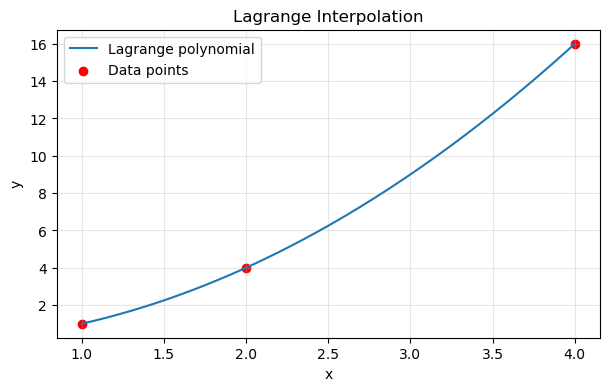

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def lagrange_interpolation(x_points, y_points, x):
    n = len(x_points)
    if n != len(y_points):
        raise ValueError("x_points and y_points must have the same length.")

    result = 0.0
    for i in range(n):
        term = y_points[i]
        for j in range(n):
            if i != j:
                term *= (x - x_points[j]) / (x_points[i] - x_points[j])
        result += term
    return result


x_pts = [1.0, 2.0, 4.0]
y_pts = [1.0, 4.0, 16.0]
x_eval = 3.0
print("Interpolated value:", lagrange_interpolation(x_pts, y_pts, x_eval))

xs = np.linspace(min(x_pts), max(x_pts), 200)
ys = [lagrange_interpolation(x_pts, y_pts, x) for x in xs]

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="Lagrange polynomial")
plt.scatter(x_pts, y_pts, color="red", label="Data points")
plt.title("Lagrange Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Time Complexity: O(n^2)

Space Complexity: O(1)

### Method 2.2: Hermite Interpolation

**Assumptions**

- x_points are distinct.
- y_points and dy_points are known at each x_points value.

**Algorithm (Hermite Interpolation)**

1. Start
2. Read x_points, y_points, dy_points, and x
3. Build z and q tables with repeated nodes
4. Fill first column of q with y values
5. Fill first divided differences using dy_points and finite differences
6. Compute higher order divided differences
7. Evaluate interpolating polynomial at x
8. Print value
9. Stop
10. End

Interpolated value: 3.375


,z,f[0],f[1],f[2],f[3]
0,1.0,1.0,NaN,NaN,NaN
1,1.0,1.0,3.0,NaN,NaN
2,2.0,8.0,7.0,4.0,NaN
3,2.0,8.0,12.0,5.0,1.0


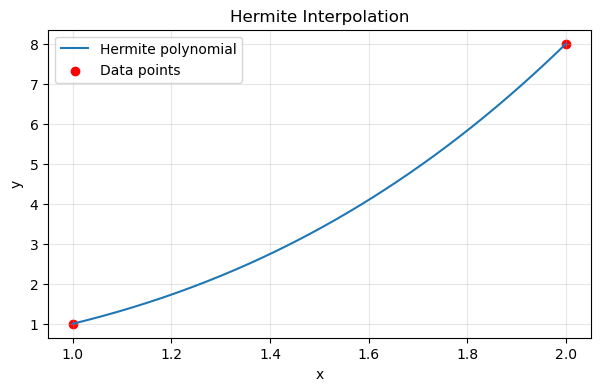

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def hermite_divided_difference(x_points, y_points, dy_points):
    n = len(x_points)
    if n != len(y_points) or n != len(dy_points):
        raise ValueError("x_points, y_points, and dy_points must have the same length.")

    size = 2 * n
    z = [0.0] * size
    q = [[0.0 for _ in range(size)] for _ in range(size)]

    for i in range(n):
        z[2 * i] = x_points[i]
        z[2 * i + 1] = x_points[i]
        q[2 * i][0] = y_points[i]
        q[2 * i + 1][0] = y_points[i]
        q[2 * i + 1][1] = dy_points[i]
        if i == 0:
            q[2 * i][1] = dy_points[i]
        else:
            q[2 * i][1] = (q[2 * i][0] - q[2 * i - 1][0]) / (z[2 * i] - z[2 * i - 1])

    for i in range(2, size):
        for j in range(2, i + 1):
            q[i][j] = (q[i][j - 1] - q[i - 1][j - 1]) / (z[i] - z[i - j])

    return z, q


def hermite_eval(z, q, x):
    value = q[0][0]
    product = 1.0
    for i in range(1, len(z)):
        product *= (x - z[i - 1])
        value += q[i][i] * product
    return value


x_pts = [1.0, 2.0]
y_pts = [1.0, 8.0]
dy_pts = [3.0, 12.0]
x_eval = 1.5
z, q = hermite_divided_difference(x_pts, y_pts, dy_pts)
print("Interpolated value:", hermite_eval(z, q, x_eval))

rows = []
for i in range(len(z)):
    row = {"z": z[i]}
    for j in range(i + 1):
        row[f"f[{j}]"] = q[i][j]
    rows.append(row)
table = pd.DataFrame(rows)
display(table)

xs = np.linspace(min(x_pts), max(x_pts), 200)
ys = [hermite_eval(z, q, x) for x in xs]

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="Hermite polynomial")
plt.scatter(x_pts, y_pts, color="red", label="Data points")
plt.title("Hermite Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Time Complexity: O(n^2)

Space Complexity: O(n^2)

### Method 2.3: Divided Difference Table

**Assumptions**

- x_points are distinct.
- y_points are known at each x_points value.

**Algorithm (Divided Difference Table)**

1. Start
2. Read x_points and y_points
3. Set first column of table to y_points
4. For each order j = 1 to n - 1, compute divided differences
5. Print table
6. Stop
7. End

,x,f[0],f[1],f[2],f[3]
0,1.0,1.0,3.0,1.0,0.0
1,2.0,4.0,6.0,1.0,NaN
2,4.0,16.0,9.0,NaN,NaN
3,5.0,25.0,NaN,NaN,NaN


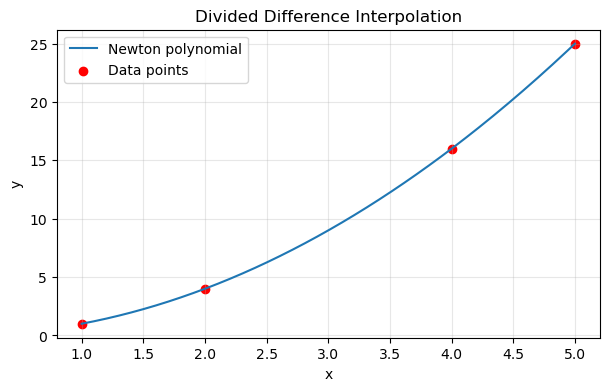

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def divided_difference_table(x_points, y_points):
    n = len(x_points)
    if n != len(y_points):
        raise ValueError("x_points and y_points must have the same length.")

    table = [[0.0 for _ in range(n)] for _ in range(n)]
    for i in range(n):
        table[i][0] = y_points[i]

    for j in range(1, n):
        for i in range(n - j):
            table[i][j] = (table[i + 1][j - 1] - table[i][j - 1]) / (x_points[i + j] - x_points[i])

    return table


def newton_divided_difference_eval(x_points, table, x):
    value = table[0][0]
    product = 1.0
    for j in range(1, len(x_points)):
        product *= (x - x_points[j - 1])
        value += table[0][j] * product
    return value


x_pts = [1.0, 2.0, 4.0, 5.0]
y_pts = [1.0, 4.0, 16.0, 25.0]
dd_table = divided_difference_table(x_pts, y_pts)

rows = []
n = len(x_pts)
for i in range(n):
    row = {"x": x_pts[i]}
    for j in range(n - i):
        row[f"f[{j}]"] = dd_table[i][j]
    rows.append(row)
table = pd.DataFrame(rows)
display(table)

xs = np.linspace(min(x_pts), max(x_pts), 200)
ys = [newton_divided_difference_eval(x_pts, dd_table, x) for x in xs]

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="Newton polynomial")
plt.scatter(x_pts, y_pts, color="red", label="Data points")
plt.title("Divided Difference Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Time Complexity: O(n^2)

Space Complexity: O(n^2)

### Method 2.4: Difference Table

**Assumptions**

- x values are equally spaced.
- y values are known for each x.

**Algorithm (Difference Table)**

1. Start
2. Read y_values
3. Set first column of table to y_values
4. For each order j = 1 to n - 1, compute forward differences
5. Print table
6. Stop
7. End

,x,d^0,d^1,d^2,d^3,d^4
0,0,1.0,7.0,12.0,6.0,0.0
1,1,8.0,19.0,18.0,6.0,NaN
2,2,27.0,37.0,24.0,NaN,NaN
3,3,64.0,61.0,NaN,NaN,NaN
4,4,125.0,NaN,NaN,NaN,NaN


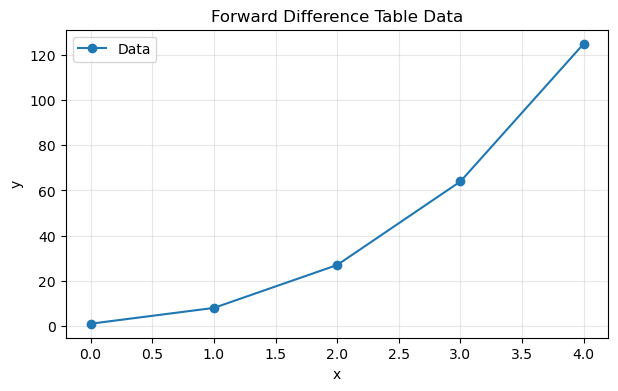

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def forward_difference_table(y_values):
    n = len(y_values)
    table = [[0.0 for _ in range(n)] for _ in range(n)]

    for i in range(n):
        table[i][0] = y_values[i]

    for j in range(1, n):
        for i in range(n - j):
            table[i][j] = table[i + 1][j - 1] - table[i][j - 1]

    return table


y_vals = [1.0, 8.0, 27.0, 64.0, 125.0]
fd_table = forward_difference_table(y_vals)

rows = []
n = len(y_vals)
for i in range(n):
    row = {"x": i}
    for j in range(n - i):
        row[f"d^{j}"] = fd_table[i][j]
    rows.append(row)
table = pd.DataFrame(rows)
display(table)

x_vals = list(range(len(y_vals)))
plt.figure(figsize=(7, 4))
plt.plot(x_vals, y_vals, marker="o", label="Data")
plt.title("Forward Difference Table Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Time Complexity: O(n^2)

Space Complexity: O(n^2)

### Method 2.5: Newton Interpolation Using Differences

**Assumptions**

- x_points are equally spaced.
- y_values are known for each x_points value.
- x is within the interpolation range.

**Algorithm (Newton Forward Interpolation)**

1. Start
2. Read x_points, y_values, and x
3. Compute h = x_points[1] - x_points[0]
4. Build forward difference table
5. Compute p = (x - x_points[0]) / h
6. Evaluate polynomial using p and forward differences
7. Print value
8. Stop
9. End

Interpolated value: 3.375


,x,d^0,d^1,d^2,d^3
0,0.0,0.0,1.0,6.0,6.0
1,1.0,1.0,7.0,12.0,NaN
2,2.0,8.0,19.0,NaN,NaN
3,3.0,27.0,NaN,NaN,NaN


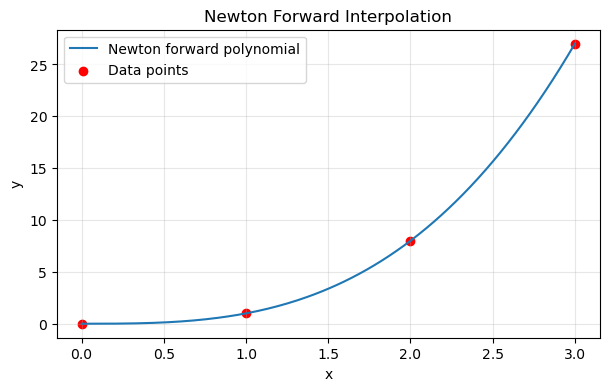

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def forward_difference_table(y_values):
    n = len(y_values)
    table = [[0.0 for _ in range(n)] for _ in range(n)]

    for i in range(n):
        table[i][0] = y_values[i]

    for j in range(1, n):
        for i in range(n - j):
            table[i][j] = table[i + 1][j - 1] - table[i][j - 1]

    return table


def newton_forward_interpolation(x_points, y_values, x):
    n = len(x_points)
    if n != len(y_values):
        raise ValueError("x_points and y_values must have the same length.")
    if n < 2:
        return y_values[0]

    h = x_points[1] - x_points[0]
    for i in range(n - 1):
        if abs((x_points[i + 1] - x_points[i]) - h) > 1e-12:
            raise ValueError("Newton forward interpolation requires equally spaced x values.")

    diff_table = forward_difference_table(y_values)
    p = (x - x_points[0]) / h

    value = diff_table[0][0]
    p_term = 1.0
    factorial = 1.0

    for k in range(1, n):
        p_term *= (p - (k - 1))
        factorial *= k
        value += (p_term / factorial) * diff_table[0][k]

    return value


x_pts = [0.0, 1.0, 2.0, 3.0]
y_vals = [0.0, 1.0, 8.0, 27.0]
x_eval = 1.5
print("Interpolated value:", newton_forward_interpolation(x_pts, y_vals, x_eval))

diff_table = forward_difference_table(y_vals)
rows = []
n = len(x_pts)
for i in range(n):
    row = {"x": x_pts[i]}
    for j in range(n - i):
        row[f"d^{j}"] = diff_table[i][j]
    rows.append(row)
table = pd.DataFrame(rows)
display(table)

xs = np.linspace(min(x_pts), max(x_pts), 200)
ys = [newton_forward_interpolation(x_pts, y_vals, x) for x in xs]

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label="Newton forward polynomial")
plt.scatter(x_pts, y_vals, color="red", label="Data points")
plt.title("Newton Forward Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Time Complexity: O(n^2)

Space Complexity: O(n^2)